In [3]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

sys.path.insert(0, '../kinetic_analysis')
# from kinetic_function import (
#                               generate_track,
#                               generate_profile
#                              )
from kineticanalysis.analysis.analysis_track import single_track_analysis

In [68]:
import ast
import sys

def top_level_functions(body):
    return (f for f in body if isinstance(f, ast.FunctionDef))

def parse_ast(filename):
    with open(filename, "rt") as file:
        return ast.parse(file.read(), filename=filename)

if __name__ == "__main__":
    for filename in sys.argv[1:]:
        print(filename)
        tree = parse_ast(filename)
        for func in top_level_functions(tree.body):
            print("  %s" % func.name)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'analysis']

In [118]:
path_save = "/home/u2175049/Documents/Code/KineticAnalysis/notebook/figures/"
path = "/mnt/sda1/Sophie/2-KineticAnalysisData/2-Datas/05-Modelling/"

In [3]:
prot_aa_size = {
    "32xsuntag": 796,  #768/32=24 , left 28
    "linker": 4,
    "twist": 490,
    "ilp4": 134,
    "snail": 390,
    "very_long_prot":2000, 
}

In [115]:
x,y  = generate_profile(0,
                        suntag_length = prot_aa_size["32xsuntag"]*2, 
                        nb_suntag=32*2, 
                        fluo_one_suntag=4, 
                        translation_rate=24, 
                        retention_time=0,
                        suntag_pos="begin",
                        step = 0.1)

In [135]:
x[-1]

66.3

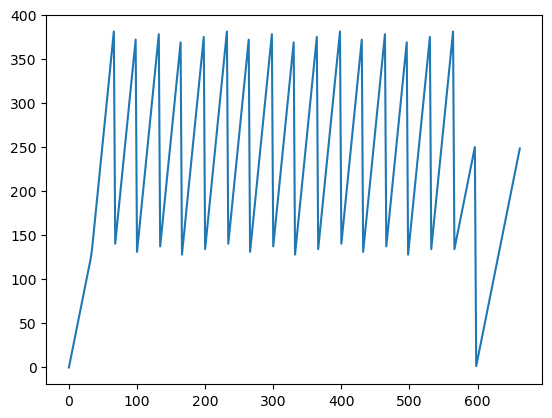

In [136]:
repeat = 10
x_global = x
for i in range(repeat-1):
    x_global = np.concatenate([x_global, x+x_global[-1]+0.1])

y_global = np.repeat([y], repeat, axis=0).flatten()

j=int(len(y)/2)
for i in range(repeat-2):
    y_global[j:j+len(y)] = y_global[j:j+len(y)] + y 
    j+=len(y)


plt.plot(x_global[::20], y_global[::20])

In [137]:
x_global[:800]

array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
        1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
        2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
        3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
        4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,
        5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,
        6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,
        7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,
        8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,
        9.9, 10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9,
       11. , 11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12. ,
       12.1, 12.2, 12.3, 12.4, 12.5, 12.6, 12.7, 12.8, 12.9, 13. , 13.1,
       13.2, 13.3, 13.4, 13.5, 13.6, 13.7, 13.8, 13.9, 14. , 14.1, 14.2,
       14.3, 14.4, 14.5, 14.6, 14.7, 14.8, 14.9, 15

In [138]:
(x_auto,
y_auto,
elongation_r,
translation_init_r,
perr) = single_track_analysis(x_global,
                              y_global,
                             delta_t=2., 
                             protein_size=prot_aa_size["32xsuntag"],
                             method="linear",
                             first_dot = False)
elongation_r, translation_init_r

linear
183


(2.1748633879781423, 46.95439709335488)

In [144]:
prot_length = prot_aa_size["32xsuntag"]
for nb in range(100):
    # x_global, y_global, y_start_prot = generate_track(prot_length = 0, 
    #                                                   suntag_length = prot_aa_size["32xsuntag"], 
    #                                                   nb_suntag=32, 
    #                                                   fluo_one_suntag=4, 
    #                                                   translation_rate=24, 
    #                                                   binding_rate=0.05,
    #                                                   step = 0.1)
    x,y  = generate_profile(0,
                        suntag_length = prot_aa_size["32xsuntag"]*2, 
                        nb_suntag=32*2, 
                        fluo_one_suntag=4, 
                        translation_rate=24, 
                        retention_time=0,
                        suntag_pos="begin",
                        step = 0.1)
    # # one prot at a time
    # repeat = 10
    # x_global = x
    # for j in range(repeat-1):
    #     x_global = np.concatenate([x_global, x+x_global[-1]+0.1])
    # y_global = np.repeat([y], repeat, axis=0).flatten()

    # two prot at a time
    repeat = 20
    x_global = x
    for i in range(repeat-1):
        x_global = np.concatenate([x_global, x+x_global[-1]+0.1])
    
    y_global = np.repeat([y], repeat, axis=0).flatten()
    
    j=331
    for i in range(repeat-2):
        y_global[j:j+len(y)] = y_global[j:j+len(y)] + y 
        j+=len(y)

    x_global = x_global[::20]
    y_global = y_global[::20]

    x_global = x_global[100:]
    y_global = y_global[100:]
    
    if nb == 0:
        datas = pd.DataFrame({"FRAME":np.arange(len(y_global)),
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : nb
                             })
    else:
        datas = pd.concat([datas, 
                           pd.DataFrame({"FRAME":np.arange(len(y_global)),
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : nb
                             })], ignore_index=True)

datas.to_csv(os.path.join(path, "datas_suntag_only_2.csv"))
print(path)

/mnt/sda1/Sophie/2-KineticAnalysisData/2-Datas/05-Modelling/


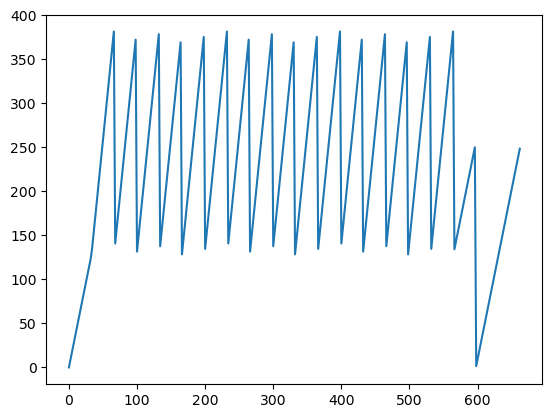

In [141]:

plt.plot(x_global, y_global)

In [33]:
datas = pd.read_csv(os.path.join(path, "datas_deltat.csv"))

In [9]:
first_time = True
for t in [1, 10, 30, 100, 300, 600]:
    dt = t*0.1
    for i in range(100):
        datas2 =datas[(datas["TRACK_ID"]==i)][::int(t)]
        (x, 
        y, 
        x_auto, 
        y_auto, 
        elongation_r, 
        translation_init_r,
        perr) = single_track_analysis(datas2,
                                     i, 
                                     delta_t = dt,
                                     protein_size=prot_length,
                                     normalise_intensity=1,
                                     normalise_auto=True,
                                     mm=None,
                                     lowpass_=False,
                                     cutoff=100,
                                     rtol=1e-1,
                                     method="linear",
                                     force_analysis=True,
                                     first_dot=True,
                                     simulation=True)
        if first_time:
            results = pd.DataFrame({"elongation_r":elongation_r, 
                                    "init_translation_r":translation_init_r, 
                                    "dt":dt,
                                   "id":i,
                                   "t":t},
                                  index=[0])
            first_time = False
        
        else:
            results = pd.concat([results, 
                            pd.DataFrame({"elongation_r":elongation_r, 
                                          "init_translation_r":translation_init_r, 
                                          "dt":dt, 
                                          "id":i,
                                         "t":t}, index=[0])
                            ], ignore_index=True)
results.to_csv(os.path.join(path, "results_deltat.csv"))

In [36]:
results.groupby(by='dt')[['elongation_r','init_translation_r']].mean()

,elongation_r,init_translation_r
dt,,
0.1,22.167509,0.040291
1.0,21.883371,0.039696
3.0,21.771451,0.039151
10.0,20.705952,0.036629
30.0,15.191154,0.027658
60.0,4.069861,-0.451663


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


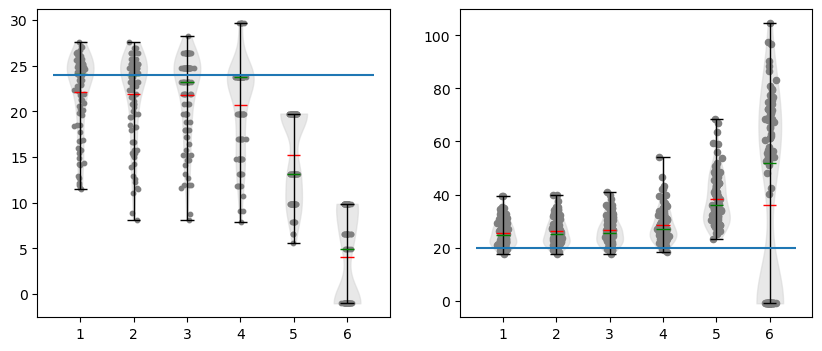

In [50]:
fig, ax = plt.subplots(1,2)

violin = ax[0].violinplot(dataset = [results[results.dt == 0.1]["elongation_r"].values,
                           results[results.dt == 1.0]["elongation_r"].values,
                          results[results.dt == 3.0]["elongation_r"].values,
                          results[results.dt == 10.0]["elongation_r"].values,
                          results[results.dt == 30.0]["elongation_r"].values,
                          results[results.dt == 60.0]["elongation_r"].values,],
                            showmeans=True,
                          showmedians=True)
for pc in violin["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("lightgrey")
    pc.set_alpha(0.5)

colors = ["black", "black", "black", "red", "green"]
i=0
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = violin[partname]
    vp.set_edgecolor(colors[i])
    vp.set_linewidth(1)
    i+=1
    


violin = ax[1].violinplot(dataset = [results[results.dt == 0.1]["init_translation_r"].values,
                           results[results.dt == 1.0]["init_translation_r"].values,
                          results[results.dt == 3.0]["init_translation_r"].values,
                          results[results.dt == 10.0]["init_translation_r"].values,
                          results[results.dt == 30.0]["init_translation_r"].values,
                          results[results.dt == 60.0]["init_translation_r"].values,],
                          showmeans=True,
                          showmedians=True)
for pc in violin["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("lightgrey")
    pc.set_alpha(0.5)
colors = ["black", "black", "black", "red", "green"]
i=0
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = violin[partname]
    vp.set_edgecolor(colors[i])
    vp.set_linewidth(1)
    i+=1
    
group = 'dt'
column = 'elongation_r'
grouped = results.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    names.append(name)
    vals.append(subdf[column].tolist())
    xs.append(np.random.normal(i+1, 0.04, subdf.shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[0].scatter(x, val, c='grey', alpha=1, s=10)
    
group = 'dt'
column = 'init_translation_r'
grouped = results.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    names.append(name)
    vals.append(subdf[column].tolist())
    xs.append(np.random.normal(i+1, 0.04, subdf.shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[1].scatter(x, val, c='grey', alpha=1, s=20)
# ax[1].set_ylim(0,0.1)
    
# ax[1].set_ylim(0,250)

ax[0].hlines(24, 0.5, 6.5)
ax[1].hlines(1/0.05, 0.5, 6.5)
fig.set_size_inches((10,4))
fig.savefig(os.path.join(path_save, "results_delta_t_boxplot_linear_diff.eps"), dpi=300)

(0.0, 100.0)

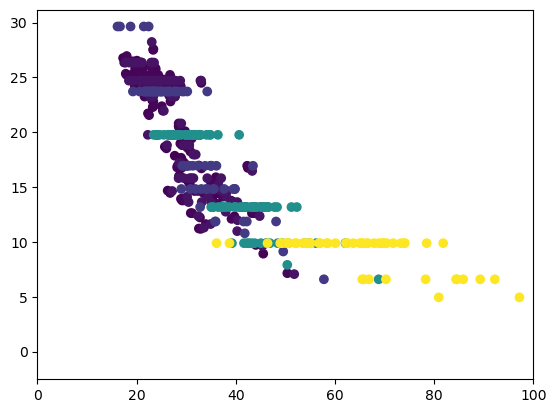

In [10]:
fig, ax = plt.subplots()
ax.scatter(results["init_translation_r"], results["elongation_r"], c=results["dt"])
ax.set_xlim(0,100)

In [11]:
from scipy.stats import bootstrap

d = (results[results.dt == 30]["elongation_r"].to_numpy(),)
bootstrap_ci = bootstrap(d,
                          np.mean, 
                          confidence_level=0.95,
                          method="percentile"
                         )
bootstrap_ci.confidence_interval

ConfidenceInterval(low=14.696166666666668, high=16.455633333333328)

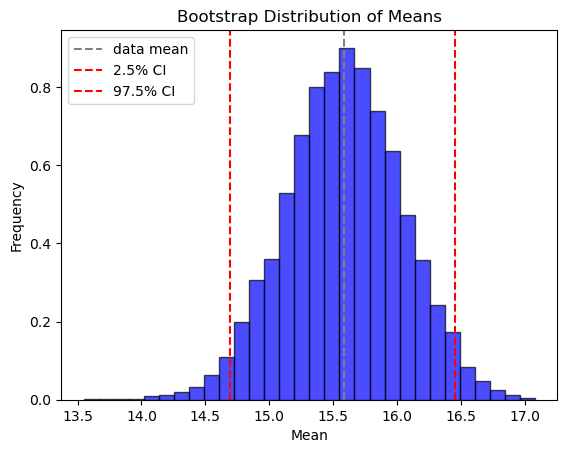

ConfidenceInterval(low=14.696166666666668, high=16.455633333333328)
Bootstrap Mean Estimate: 	15.583806298407618
Bootstrap Median Estimate: 	15.585899999999997
Bootstrap Standard Error: 	0.45371163475131904
Mean: 	15.585899999999997
Bootstrap Bias: -0.0020937015923792046


In [12]:
import matplotlib.pyplot as plt

plt.hist(bootstrap_ci.bootstrap_distribution, density=True, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.title('Bootstrap Distribution of Means')
plt.xlabel('Mean')
plt.ylabel('Frequency')
plt.axvline(np.mean(d)  , color='grey', linestyle='dashed', label='data mean')
plt.axvline(bootstrap_ci.confidence_interval.low, color='red', linestyle='dashed', label='2.5% CI')
plt.axvline(bootstrap_ci.confidence_interval.high, color='red', linestyle='dashed', label='97.5% CI')
plt.legend()
plt.show()

print(bootstrap_ci.confidence_interval)
# calculate central tendency
mean_estimate = np.mean(bootstrap_ci.bootstrap_distribution)
median_estimate = np.median(bootstrap_ci.bootstrap_distribution)
print(f"Bootstrap Mean Estimate: \t{mean_estimate}")
print(f"Bootstrap Median Estimate: \t{median_estimate}")

# measure variability
standard_error = np.std(bootstrap_ci.bootstrap_distribution)
print(f"Bootstrap Standard Error: \t{standard_error}")

# Assess bias
original_statistic = np.mean(d)  
print(f"Mean: \t{original_statistic}")
bias = np.mean(bootstrap_ci.bootstrap_distribution) - original_statistic
print(f"Bootstrap Bias: {bias}")



In [13]:
result_group = results.groupby(by='dt')[['elongation_r','init_translation_r']].mean()
result_group

,elongation_r,init_translation_r
dt,,
0.1,21.378998,26.816988
1.0,20.943686,27.428859
3.0,20.401166,28.251733
10.0,19.893238,29.871447
30.0,15.585900,37.101840
60.0,4.584028,36.979017


In [14]:
result_group["ratio"] = 100*result_group["elongation_r"]/24
result_group

,elongation_r,init_translation_r,ratio
dt,,,
0.1,21.378998,26.816988,89.079159
1.0,20.943686,27.428859,87.265357
3.0,20.401166,28.251733,85.004857
10.0,19.893238,29.871447,82.888491
30.0,15.585900,37.101840,64.941250
60.0,4.584028,36.979017,19.100116


In [11]:
results[3::100]

,elongation_r,init_translation_r,dt,id
3,23.392505,0.039939,0.1,3
103,22.377358,0.038642,1.0,3
203,23.254902,0.038979,3.0,3
303,23.720000,0.038400,10.0,3
403,19.766667,0.032540,30.0,3
503,9.883333,0.014135,60.0,3


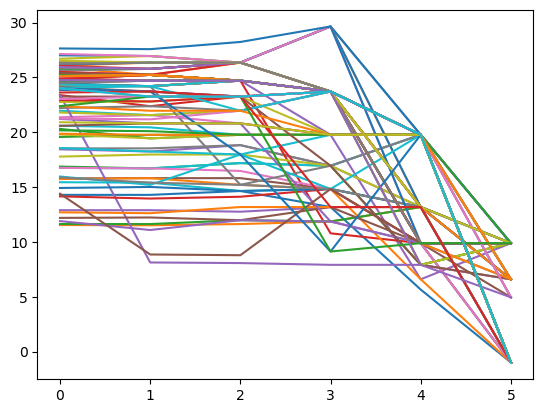

In [12]:
fig, ax = plt.subplots()
for i in range(100):
    ax.plot(range(6), results[i::100]["elongation_r"])

In [13]:
results

,elongation_r,init_translation_r,dt,id
0,24.863732,0.043771,0.1,0
1,26.065934,0.040075,0.1,1
2,19.570957,0.030959,0.1,2
3,23.392505,0.039939,0.1,3
4,25.287846,0.046100,0.1,4
...,...,...,...,...
595,-1.000000,-1.000000,60.0,95
596,-1.000000,-1.000000,60.0,96
597,-1.000000,-1.000000,60.0,97
598,-1.000000,-1.000000,60.0,98


In [9]:
datas[datas["TRACK_ID"]==0][::10]

,Unnamed: 0,FRAME,MEAN_INTENSITY_CH1,TRACK_ID
0,0,0.0,595.6,0
10,10,1.0,607.6,0
20,20,2.0,491.6,0
30,30,3.0,503.6,0
40,40,4.0,515.6,0
...,...,...,...,...
57950,57950,5795.0,5.2,0
57960,57960,5796.0,9.2,0
57970,57970,5797.0,13.2,0
57980,57980,5798.0,17.2,0


In [4]:
repo = ['/home/u2175049/Downloads/5aa',
       '/home/u2175049/Downloads/24aa',
       '/home/u2175049/Downloads/72aa',]

list_file = ['datas_results_0.csv',
             'datas_results_50.csv',
             'datas_results_100.csv',
            'datas_results_500.csv',
            'datas_results_1000.csv',
            'datas_results_2000.csv',
            'datas_results_3000.csv',
            'datas_results_4000.csv',
            'datas_results_4500.csv',
            'datas_results_5000.csv']


i=0
for r in repo:
    for f in list_file :
        d_result = pd.read_csv(os.path.join(r,f))
        d_result["speed"] = int(r.split("/")[-1].split("aa")[0])
        d_result["length"] = int(f.split("_")[-1].split(".")[0])
        
        if i == 0:
            result_all = d_result.copy()
            i+=1
        else:
            result_all = pd.concat([result_all, d_result], ignore_index=True)

In [5]:
result_all["elongation_norm"] = result_all["elongation_r"]/result_all["speed"]
result_all


,id,dt,length,elongation_r,init_translation_r,perr0,perr1,comment,speed,elongation_norm
0,0,0.1,0,4.425474,0.797499,1.992713,0.013890,NaN,5,0.885095
1,1,0.1,0,7.882185,0.495772,1.073322,0.021426,NaN,5,1.576437
2,2,0.1,0,7.929242,0.565594,0.918465,0.016178,NaN,5,1.585848
3,3,0.1,0,7.117650,0.717223,1.030434,0.012849,NaN,5,1.423530
4,4,0.1,0,5.610191,1.222758,1.849966,0.010670,NaN,5,1.122038
...,...,...,...,...,...,...,...,...,...,...
295,5,0.1,5000,69.220398,1.042217,0.869587,0.009968,NaN,72,0.961394
296,6,0.1,5000,87.936416,0.873936,1.194361,0.020729,NaN,72,1.221339
297,7,0.1,5000,75.891602,0.870920,0.906459,0.013631,NaN,72,1.054050
298,8,0.1,5000,86.788837,0.692852,0.794493,0.017171,NaN,72,1.205401


/tmp/ipykernel_584926/1947351055.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for patch, color in zip(bplot[0][1]['boxes'], np.repeat([colors], 10).flatten()):


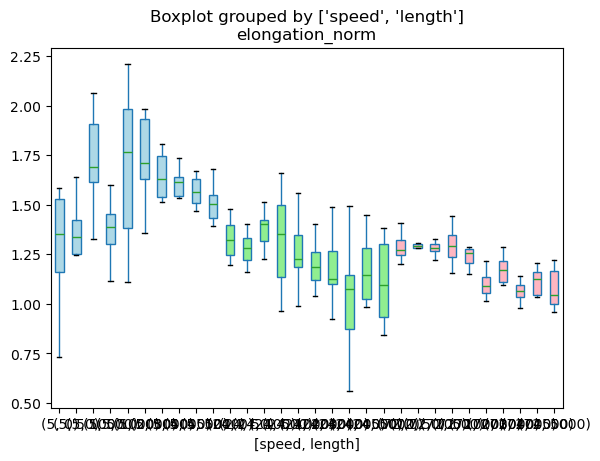

In [25]:
fig, ax = plt.subplots()


bplot = result_all.boxplot(column="elongation_norm", by=["speed","length",],  
                           ax=ax, grid = False, showfliers=False,
                          patch_artist=True,return_type='both',)

colors = ['lightblue', 'lightgreen', 'lightpink']
for patch, color in zip(bplot[0][1]['boxes'], np.repeat([colors], 10).flatten()):
    patch.set_facecolor(color)

In [32]:
np.repeat([colors], 10, axis=0).flatten()

array(['lightblue', 'lightgreen', 'lightpink', 'lightblue', 'lightgreen',
       'lightpink', 'lightblue', 'lightgreen', 'lightpink', 'lightblue',
       'lightgreen', 'lightpink', 'lightblue', 'lightgreen', 'lightpink',
       'lightblue', 'lightgreen', 'lightpink', 'lightblue', 'lightgreen',
       'lightpink', 'lightblue', 'lightgreen', 'lightpink', 'lightblue',
       'lightgreen', 'lightpink', 'lightblue', 'lightgreen', 'lightpink'],
      dtype='<U10')

<Axes: title={'center': 'elongation_r'}, xlabel='length'>

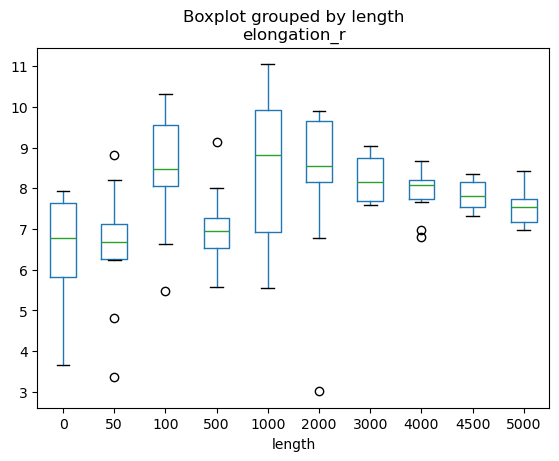

In [29]:
fig, ax = plt.subplots()

result_all[result_all["speed"]==5].boxplot(column="elongation_r", by="length",  ax=ax, grid = False, )

<Axes: title={'center': 'elongation_r'}, xlabel='length'>

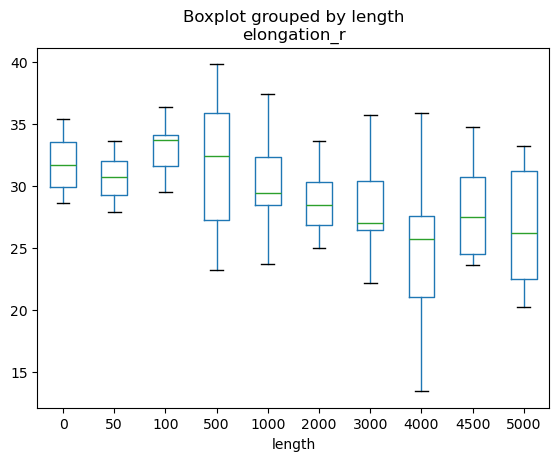

In [30]:
fig, ax = plt.subplots()

result_all[result_all["speed"]==24].boxplot(column="elongation_r", by="length",  ax=ax, grid = False, showfliers=False)

<Axes: title={'center': 'elongation_r'}, xlabel='length'>

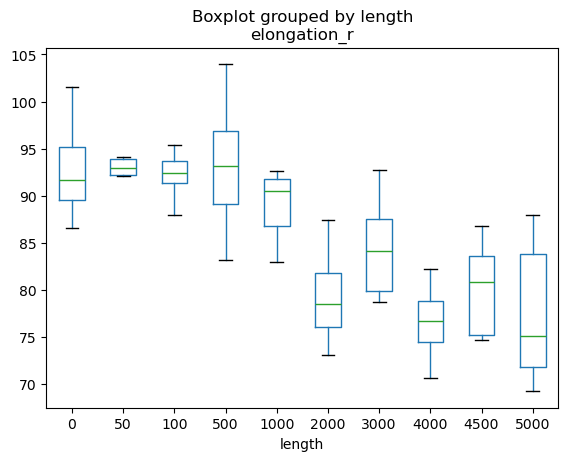

In [31]:
fig, ax = plt.subplots()

result_all[result_all["speed"]==72].boxplot(column="elongation_r", by="length",  ax=ax, grid = False, showfliers=False )

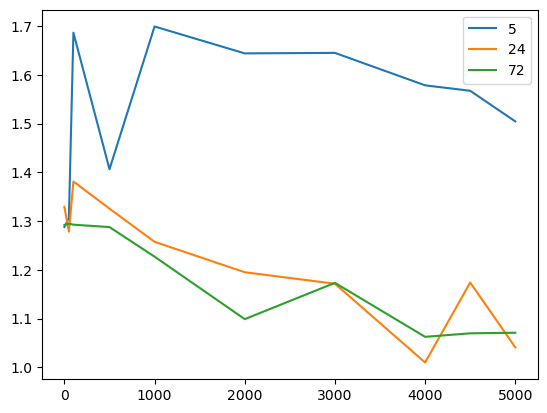

In [20]:
fig, ax = plt.subplots()

for sp in [5, 24, 72]:
# sp = 72

    ax.plot(np.unique(result_all[result_all["speed"]==sp]["length"]),
            result_all[result_all["speed"]==sp].groupby("length").mean()["elongation_norm"].to_numpy(),
           label = sp)
    
    # result_all[result_all["speed"]==sp].boxplot(column="elongation_norm", 
    #                                            by="length",  
    #                                            ax=ax, 
    #                                            grid = False, 
    #                                            showfliers= False,
    #                                            positions = np.unique(result_all[result_all["speed"]==5]["length"]))

ax.legend()
# ax.plot(np.unique(result_all[result_all["speed"]==24]["length"]),
#         result_all[result_all["speed"]==24].groupby("length").mean()["elongation_r"],)

# ax.plot(np.unique(result_all[result_all["speed"]==72]["length"]),
#         result_all[result_all["speed"]==72].groupby("length").mean()["elongation_r"],)

In [42]:
result_all[result_all["speed"]==72].groupby("length").mean()["elongation_r"]

length
0       93.016451
50      93.229571
100     93.071759
500     92.719338
1000    88.346984
2000    79.118604
3000    84.477923
4000    76.504602
4500    77.022928
5000    77.109028
Name: elongation_r, dtype: float64

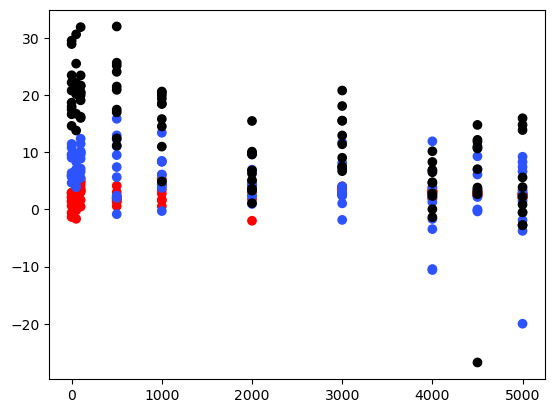

In [251]:
fig, ax = plt.subplots()

ax.scatter(result_all["length"], 
           result_all["elong_diff"], 
           c=result_all["speed"], 
           cmap="flag" ) 

In [3]:
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO

In [10]:
import pprint
from BCBio.GFF import GFFExaminer

in_file = "/home/u2175049/Downloads/Drosophila_melanogaster.BDGP6.54.115.chr.gff3"
examiner = GFFExaminer()
in_handle = open(in_file)
pprint.pprint(examiner.available_limits(in_handle))
in_handle.close()

{'gff_id': {('2L',): 89716,
            ('2R',): 105038,
            ('3L',): 94208,
            ('3R',): 115901,
            ('4',): 8992,
            ('X',): 91330,
            ('Y',): 830,
            ('mitochondrion_genome',): 128},
 'gff_source': {('BDGP6.54',): 8, ('FlyBase',): 506135},
 'gff_source_type': {('BDGP6.54', 'region'): 8,
                     ('FlyBase', 'CDS'): 163267,
                     ('FlyBase', 'exon'): 196593,
                     ('FlyBase', 'five_prime_UTR'): 46785,
                     ('FlyBase', 'gene'): 13981,
                     ('FlyBase', 'mRNA'): 30796,
                     ('FlyBase', 'miRNA'): 481,
                     ('FlyBase', 'ncRNA'): 3051,
                     ('FlyBase', 'ncRNA_gene'): 4003,
                     ('FlyBase', 'pre_miRNA'): 260,
                     ('FlyBase', 'pseudogene'): 331,
                     ('FlyBase', 'pseudogenic_transcript'): 357,
                     ('FlyBase', 'rRNA'): 101,
                     ('FlyBase', '

In [13]:
import gffutils

# Create a database from the GFF3 file
db = gffutils.create_db("/home/u2175049/Downloads/Drosophila_melanogaster.BDGP6.54.115.chr.gff3", dbfn="input.db", force=True, keep_order=True, merge_strategy="merge", sort_attribute_values=True)

# Extract summary statistics
gene_count = db.count_features_of_type("gene")
exon_count = db.count_features_of_type("exon")
mRNA_count = db.count_features_of_type("mRNA")

print("Number of genes:", gene_count)
print("Number of exons:", exon_count)
print("Number of mRNAs:", mRNA_count)

Number of genes: 13981
Number of exons: 196593
Number of mRNAs: 30796


In [15]:
# Create a database from the GFF3/GTF file
# db = gffutils.create_db("/home/u2175049/Downloads/Drosophila_melanogaster.BDGP6.54.115.chr.gff3", dbfn="input.db", force=True, keep_order=True, merge_strategy="merge", sort_attribute_values=True)

# Calculate gene lengths
gene_lengths = {}
for gene in db.features_of_type("gene"):
    gene_length = 0
    for exon in db.children(gene, featuretype="exon"):
        exon_length = exon.end - exon.start + 1
        gene_length += exon_length
    gene_lengths[gene.id] = gene_length

# Print gene lengths
for gene_id, length in gene_lengths.items():
    print(f"{gene_id}: {length}")

gene:FBgn0002121: 58024
gene:FBgn0031209: 2629
gene:FBgn0051973: 46845
gene:FBgn0067779: 19167
gene:FBgn0031213: 7959
gene:FBgn0031214: 1378
gene:FBgn0002931: 3887
gene:FBgn0031216: 6476
gene:FBgn0031217: 2804
gene:FBgn0026787: 2551
gene:FBgn0005278: 26228
gene:FBgn0031228: 6187
gene:FBgn0031219: 1942
gene:FBgn0031220: 25055
gene:FBgn0288229: 11246
gene:FBgn0001142: 6271
gene:FBgn0051975: 3541
gene:FBgn0051976: 3220
gene:FBgn0051974: 5126
gene:FBgn0031224: 905
gene:FBgn0259818: 10604
gene:FBgn0031227: 1699
gene:FBgn0031229: 2642
gene:FBgn0053635: 769
gene:FBgn0016977: 150076
gene:FBgn0031231: 903
gene:FBgn0031232: 2549
gene:FBgn0031233: 9152
gene:FBgn0266557: 98166
gene:FBgn0031235: 1660
gene:FBgn0283652: 2086
gene:FBgn0031238: 5278
gene:FBgn0031239: 11597
gene:FBgn0031240: 2417
gene:FBgn0086912: 1756
gene:FBgn0086856: 1689
gene:FBgn0086855: 9441
gene:FBgn0003444: 4008
gene:FBgn0031244: 3606
gene:FBgn0031245: 5192
gene:FBgn0025686: 3574
gene:FBgn0031247: 748
gene:FBgn0017457: 2916
gene

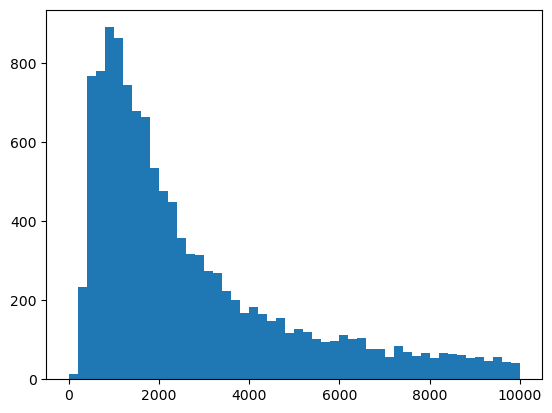

In [27]:
lengths = []
for gene_id, length in gene_lengths.items():
    lengths.append(length)

fig, ax = plt.subplots()
# ax.scatter(lengths, lengths)
# ax.set_xlim(0,10000)
# ax.set_ylim(0,10000)

_=ax.hist(lengths, bins=50, range=(0,10000))


